# Stage 5: Explainable AI (XAI) + Fairness Core

**Objective**: Transform the Stage-3 tree model from a "black-box predictor" into an auditable, explainable, and regulator-ready system.

**Sub-stages**:
- **5a**: Global explanations — SHAP summary, feature importance, PDP, feature interaction
- **5b**: Local explanations — SHAP waterfall/force, LIME, counterfactual (DiCE)
- **5c**: Counterfactual explanations — "What would need to change for approval?"
- **5d**: XAI evaluation — faithfulness, stability, comprehensibility
- **5e**: Fairness audit — Demographic Parity, Equal Opportunity, Disparate Impact
- **5f**: Fairness mitigation — Reweighing, Threshold Optimizer, trade-off analysis

**Output**: `results/analysis_reports/` — XAI plots, fairness tables; `results/models/` — mitigated models

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import time
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('muted')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'results' / 'analysis_reports'
MODEL_DIR = PROJECT_ROOT / 'results' / 'models'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR}')
print(f'Model dir:    {MODEL_DIR}')
print(f'Report dir:   {REPORT_DIR}')

Project root: /home/ubuntu/project_proposals_financial
Data dir:     /home/ubuntu/project_proposals_financial/data/processed
Model dir:    /home/ubuntu/project_proposals_financial/results/models
Report dir:   /home/ubuntu/project_proposals_financial/results/analysis_reports


In [2]:
# Load processed data
train = pd.read_parquet(DATA_DIR / 'train.parquet')
val = pd.read_parquet(DATA_DIR / 'val.parquet')
test = pd.read_parquet(DATA_DIR / 'test.parquet')

print(f'Train: {train.shape[0]:,} rows, bad_rate={train["is_bad"].mean():.2%}')
print(f'Val:   {val.shape[0]:,} rows, bad_rate={val["is_bad"].mean():.2%}')
print(f'Test:  {test.shape[0]:,} rows, bad_rate={test["is_bad"].mean():.2%}')

Train: 451,060 rows, bad_rate=16.96%
Val:   375,546 rows, bad_rate=20.19%
Test:  293,105 rows, bad_rate=23.29%


In [3]:
from src.models.tree_models import prepare_features, make_model, predict_proba, load_model

X_train, y_train, num_cols, cat_cols = prepare_features(train)
X_val, y_val, _, _ = prepare_features(val)
X_test, y_test, _, _ = prepare_features(test)

print(f'Features: {X_train.shape[1]} ({len(num_cols)} numeric, {len(cat_cols)} categorical)')
print(f'X_test: {X_test.shape[0]:,} samples')

# ---------- Load best Stage 3 model ----------
# Try optimized models first, then fall back to baseline
best_model = None
model_label = ""

load_order = [
    ('lgb_optuna_stage3.pkl', 'LightGBM (Optuna)'),
    ('xgb_optuna_stage3.pkl', 'XGBoost (Optuna)'),
    ('stacking_stage3.pkl', 'Stacking Ensemble'),
]

for fname, label in load_order:
    path = MODEL_DIR / fname
    if path.exists():
        try:
            best_model = load_model(path)
            model_label = label
            print(f'Loaded: {label} ({path.stat().st_size / 1024:.0f} KB)')
            break
        except Exception as e:
            print(f'Failed to load {fname}: {e}')

if best_model is None:
    # Fallback: train a quick LightGBM with default params
    print('No saved Stage 3 model found. Training a quick default LightGBM...')
    from src.models.tree_models import train_model as tm_train
    best_model = make_model('lgb')
    tm_train(best_model, X_train, y_train, X_val, y_val, cat_features=cat_cols)
    model_label = 'LightGBM (default)'

# Verify model works
test_preds = predict_proba(best_model, X_test)
from sklearn.metrics import roc_auc_score
print(f'Test AUC: {roc_auc_score(y_test, test_preds):.4f}')
print(f'Using model: {model_label}')

Features: 62 (55 numeric, 7 categorical)
X_test: 293,105 samples
Loaded: LightGBM (Optuna) (3421 KB)
Test AUC: 0.7184
Using model: LightGBM (Optuna)


In [4]:
# Load Stage 2 scorecard for comparison
from src.models.scorecard import Scorecard

scorecard = None
sc_path = MODEL_DIR / 'scorecard_stage2.pkl'
if sc_path.exists():
    scorecard = Scorecard.load(sc_path)
    sc_preds = scorecard.predict_score(test)
    print(f'Stage 2 Scorecard loaded — Test AUC (scaled score): {roc_auc_score(y_test, sc_preds):.4f}')
else:
    print('Scorecard not found — skipping Stage 2 comparison')

Stage 2 Scorecard loaded — Test AUC (scaled score): 0.2960


---
# Part 1: Global Explanations (5a)
---

Global explanations reveal **which features drive the model overall**, answering:
- What matters most for predicting default?
- Are the feature effects directionally sensible?
- Do different models agree on what is important?

In [5]:
import shap
from src.xai.explainer import explain_shap, shap_feature_importance

print('Computing SHAP values...')
# Use a sample for SHAP (TreeSHAP is fast but we still limit for plotting)
X_test_sample = X_test.sample(min(2000, len(X_test)), random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

t0 = time.time()
shap_result = explain_shap(best_model, X_test_sample, max_display=20)
elapsed = time.time() - t0
print(f'SHAP computed in {elapsed:.1f}s')
print(f'Expected value (base): {shap_result["expected_value"]:.4f}')
print(f'Top 10 features by mean |SHAP|:')
print(shap_result['mean_abs_shap'].head(10).to_string())

Computing SHAP values...
SHAP computed in 8.5s
Expected value (base): 1.3025
Top 10 features by mean |SHAP|:
int_rate                0.395260
term                    0.221444
annual_inc              0.150820
acc_open_past_24mths    0.114857
dti                     0.111530
fico_range_low          0.071323
loan_amnt               0.071060
mths_since_recent_bc    0.045597
mo_sin_old_rev_tl_op    0.044329
emp_length              0.042376


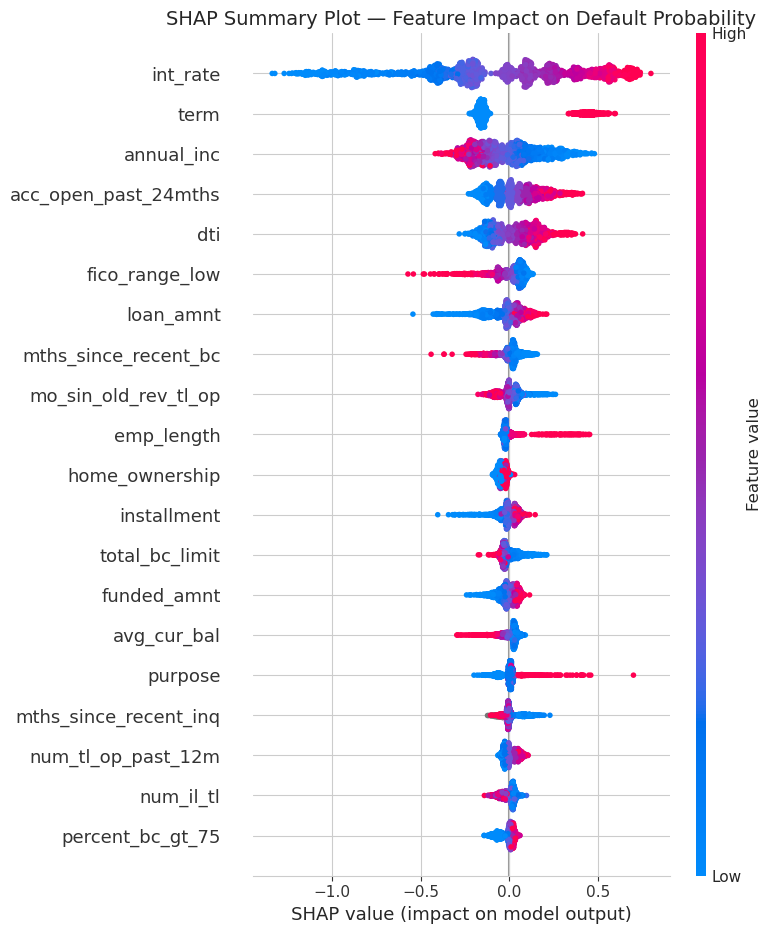

In [6]:
# SHAP summary plot (dot)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_result['shap_values'],
    X_test_sample,
    feature_names=shap_result['feature_names'],
    max_display=20,
    show=False,
    plot_type='dot',
)
ax.set_title('SHAP Summary Plot — Feature Impact on Default Probability', fontsize=14)
plt.tight_layout()
plt.savefig(REPORT_DIR / '23_shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()

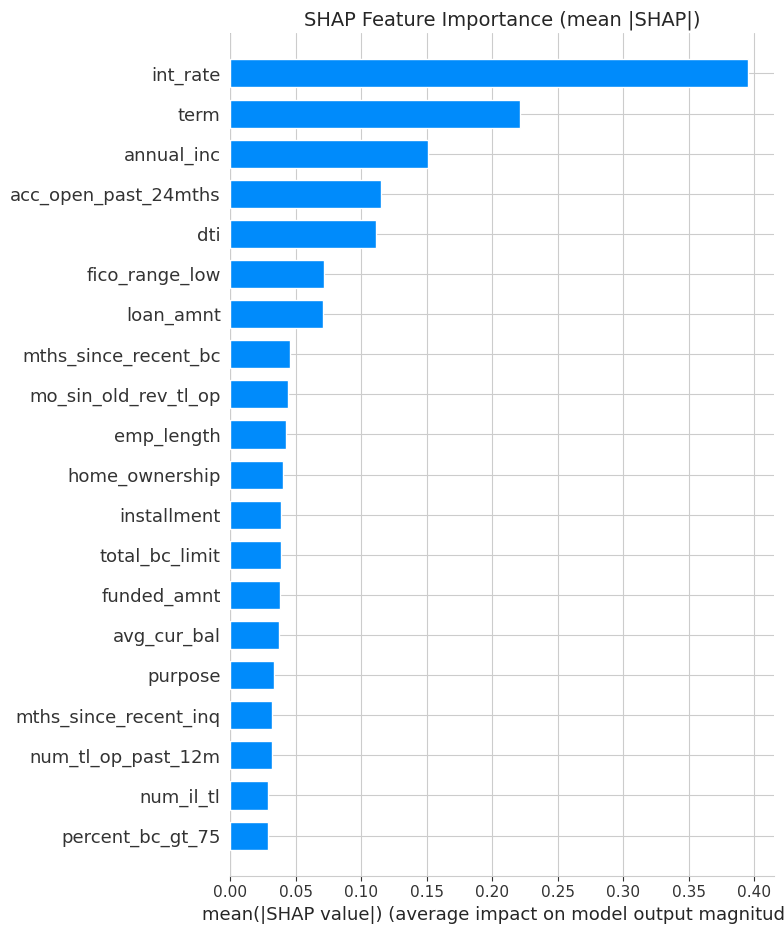

In [7]:
# SHAP bar chart (mean |SHAP|)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_result['shap_values'],
    X_test_sample,
    feature_names=shap_result['feature_names'],
    max_display=20,
    show=False,
    plot_type='bar',
)
ax.set_title('SHAP Feature Importance (mean |SHAP|)', fontsize=14)
plt.tight_layout()
plt.savefig(REPORT_DIR / '24_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Format SHAP importance as a table
fi_df = shap_feature_importance(shap_result, top_k=20)
fi_df.columns = ['Feature', 'Mean |SHAP|', 'Rank']
print(f'{"Top 20 Features by SHAP Importance":^60}')
print('=' * 60)
print(fi_df.to_string(index=False))
fi_df.to_csv(REPORT_DIR / 'shap_feature_importance.csv', index=False)

             Top 20 Features by SHAP Importance             
              Feature  Mean |SHAP|  Rank
             int_rate     0.395260     1
                 term     0.221444     2
           annual_inc     0.150820     3
 acc_open_past_24mths     0.114857     4
                  dti     0.111530     5
       fico_range_low     0.071323     6
            loan_amnt     0.071060     7
 mths_since_recent_bc     0.045597     8
 mo_sin_old_rev_tl_op     0.044329     9
           emp_length     0.042376    10
       home_ownership     0.039880    11
          installment     0.038913    12
       total_bc_limit     0.038294    13
          funded_amnt     0.037629    14
          avg_cur_bal     0.037020    15
              purpose     0.032964    16
mths_since_recent_inq     0.031571    17
   num_tl_op_past_12m     0.031453    18
            num_il_tl     0.028949    19
     percent_bc_gt_75     0.028880    20


Top-20 overlap (Jaccard): 14/26 = 53.85%
In native top-20 but not SHAP: {'mo_sin_old_il_acct', 'bc_util', 'bc_open_to_buy', 'total_rev_hi_lim', 'mo_sin_rcnt_tl', 'revol_bal'}
In SHAP top-20 but not native: {'num_il_tl', 'num_tl_op_past_12m', 'funded_amnt', 'term', 'home_ownership', 'percent_bc_gt_75'}


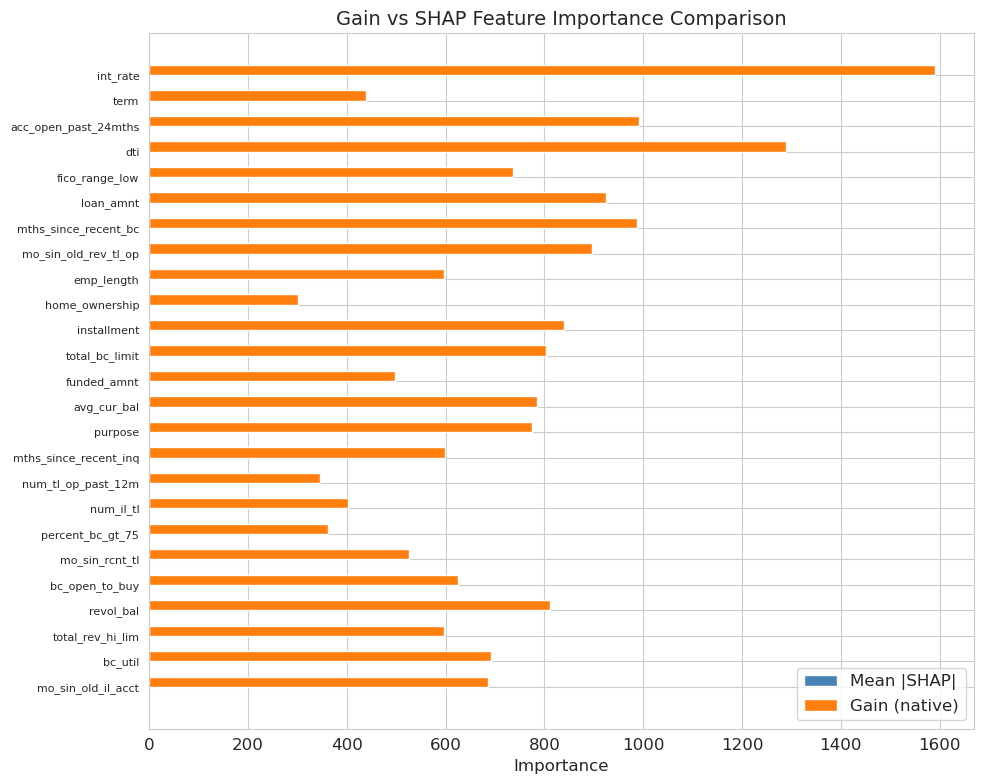

In [9]:
# Compare model-native feature importance vs SHAP
model_type = type(best_model).__name__.lower()
native_imp = None

if hasattr(best_model, 'feature_importances_'):
    native_imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
elif hasattr(best_model, 'get_score'):
    imp_dict = best_model.get_score(importance_type='gain')
    native_imp = pd.Series(imp_dict)
    # Align feature names
    native_imp = native_imp.reindex(X_train.columns).fillna(0)

if native_imp is not None:
    native_imp = native_imp.sort_values(ascending=False)
    shap_imp = shap_result['mean_abs_shap']
    
    # Top-20 overlap
    native_top20 = set(native_imp.head(20).index)
    shap_top20 = set(shap_imp.head(20).index)
    overlap = native_top20 & shap_top20
    print(f'Top-20 overlap (Jaccard): {len(overlap)}/{len(native_top20 | shap_top20)} = {len(overlap)/len(native_top20 | shap_top20):.2%}')
    print(f'In native top-20 but not SHAP: {native_top20 - shap_top20}')
    print(f'In SHAP top-20 but not native: {shap_top20 - native_top20}')
    
    # Comparison bar chart
    common = list(native_top20 | shap_top20)[:25]
    comp = pd.DataFrame({
        'Gain': native_imp.reindex(common).fillna(0),
        'SHAP': shap_imp.reindex(common).fillna(0),
    }).sort_values('SHAP', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    x = range(len(comp))
    ax.barh(x, comp['SHAP'], height=0.4, label='Mean |SHAP|', color='steelblue')
    ax.barh([i+0.4 for i in x], comp['Gain'], height=0.4, label='Gain (native)', color='#ff7f0e')
    ax.set_yticks([i+0.2 for i in x])
    ax.set_yticklabels(comp.index, fontsize=8)
    ax.set_xlabel('Importance')
    ax.set_title('Gain vs SHAP Feature Importance Comparison')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORT_DIR / '25_gain_vs_shap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Model does not expose native feature_importances_ or get_score()')

Computing PDP for: ['int_rate', 'term', 'annual_inc', 'acc_open_past_24mths', 'dti', 'fico_range_low']
PDPs computed in 9.3s


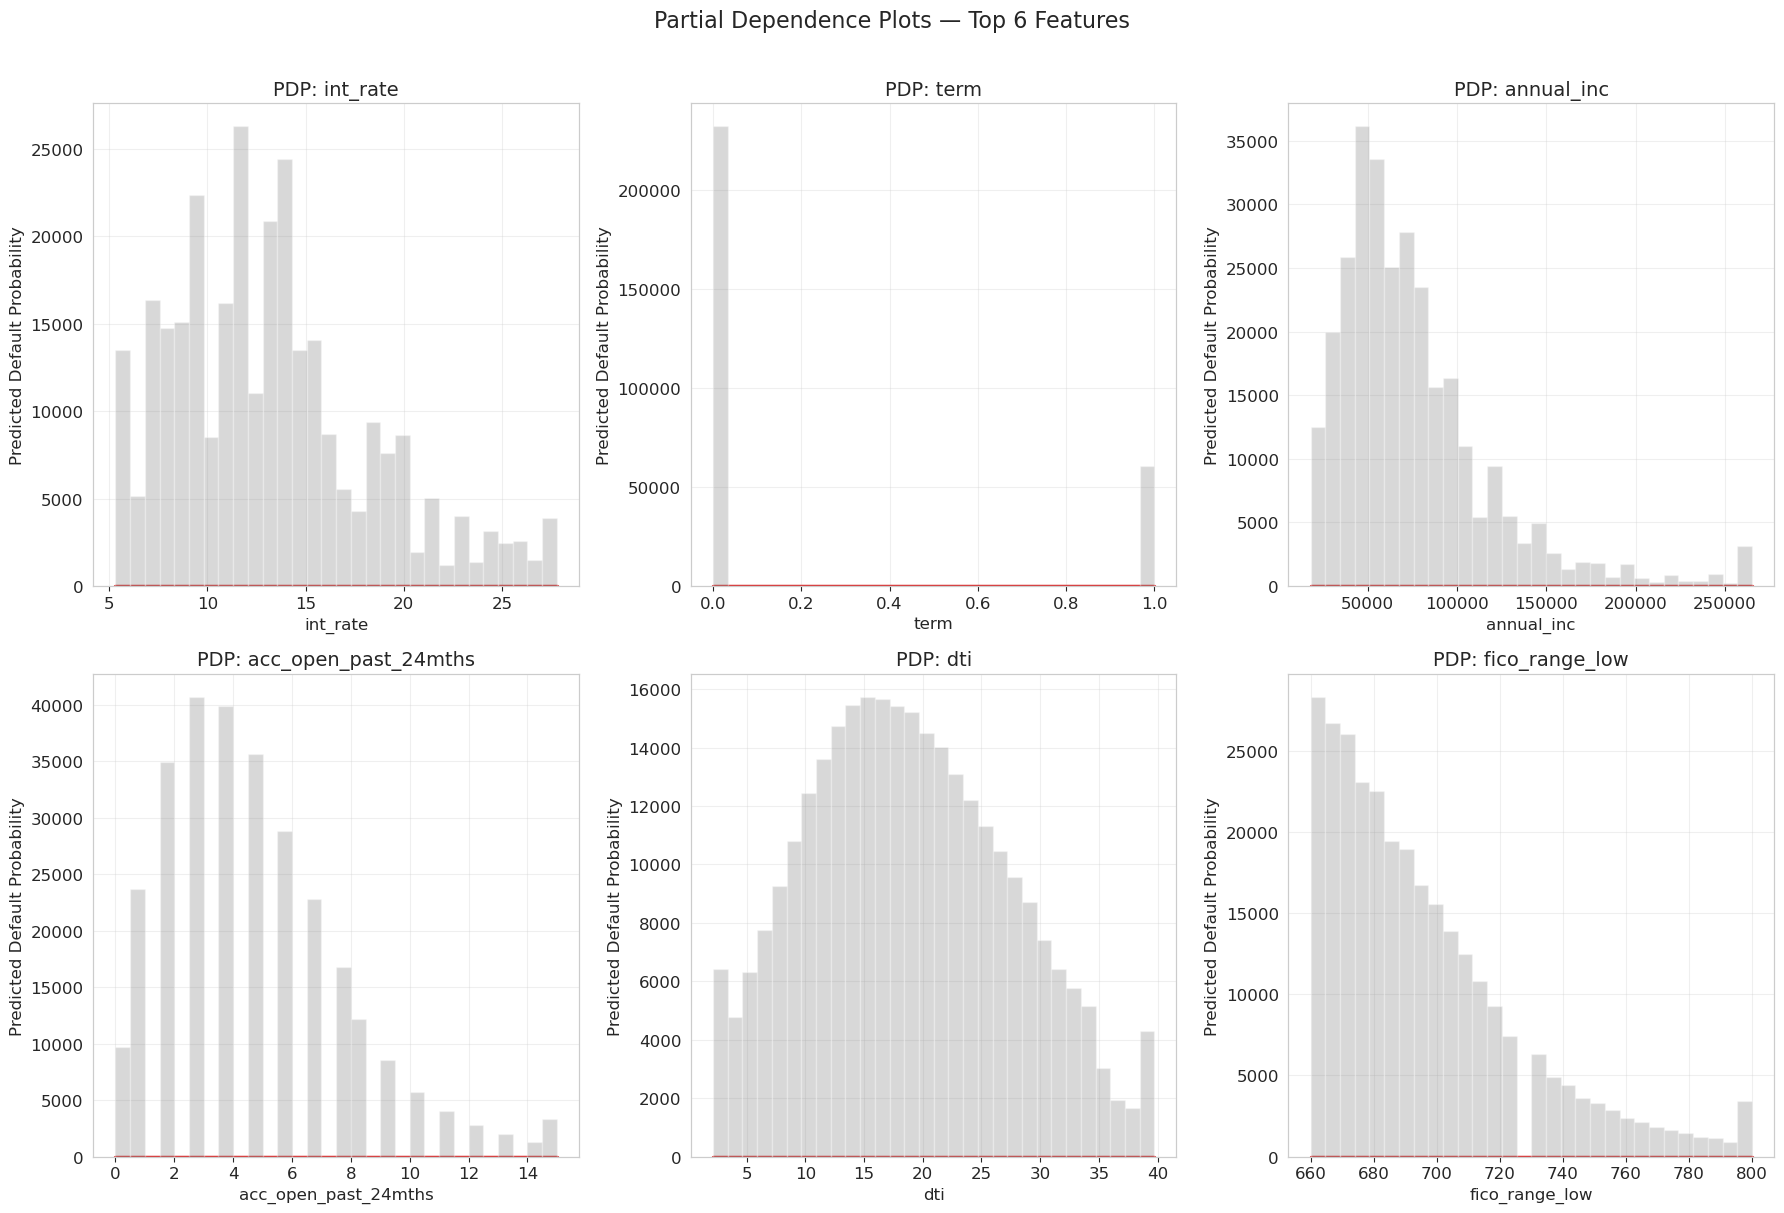

In [10]:
from src.xai.explainer import compute_pdp_multi

# Select top 6 features by SHAP for PDP
top6_feats = shap_result['mean_abs_shap'].head(6).index.tolist()
print(f'Computing PDP for: {top6_feats}')

t0 = time.time()
pdps = compute_pdp_multi(best_model, X_test_sample, top6_feats, grid_points=30)
print(f'PDPs computed in {time.time()-t0:.1f}s')

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(top6_feats):
    ax = axes[i]
    pdp = pdps[feat]
    ax.plot(pdp['grid'], pdp['pdp_values'], lw=2.5, color='#d62728')
    ax.fill_between(pdp['grid'], pdp['pdp_values'], alpha=0.15, color='#d62728')
    ax.set_xlabel(feat)
    ax.set_ylabel('Predicted Default Probability')
    ax.set_title(f'PDP: {feat}')
    ax.grid(True, alpha=0.3)
    
    # Add rug plot (density of actual values)
    vals = X_test[feat].dropna()
    ax2 = ax.twiny()
    ax2.hist(vals.clip(lower=vals.quantile(0.01), upper=vals.quantile(0.99)), 
             bins=30, alpha=0.3, color='gray')
    ax2.set_xticks([])

fig.suptitle('Partial Dependence Plots — Top 6 Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(REPORT_DIR / '26_pdp_top6.png', dpi=150, bbox_inches='tight')
plt.show()

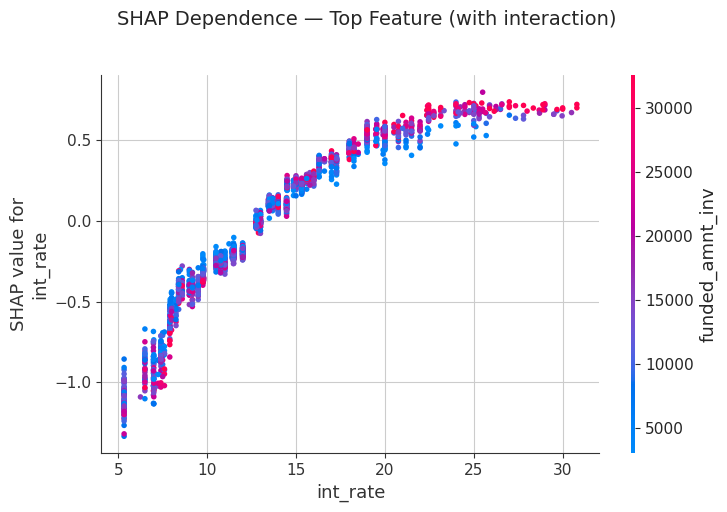

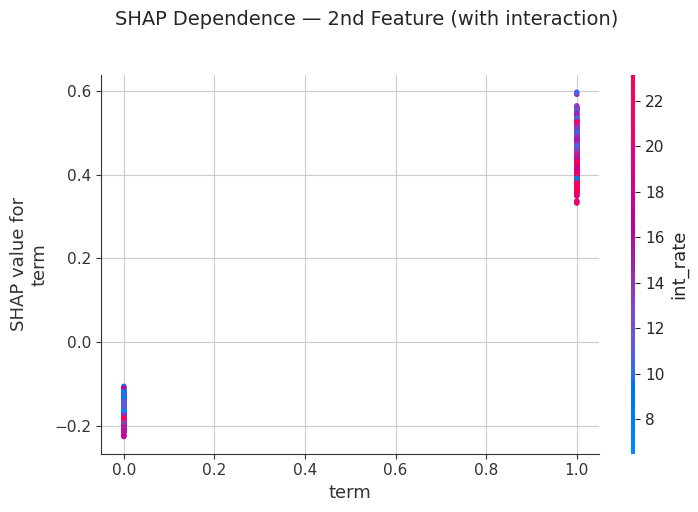

In [11]:
# SHAP dependence plots for top features (shows interaction with strongest interacting feature)
shap.dependence_plot(
    'rank(0)', shap_result['shap_values'], X_test_sample,
    feature_names=shap_result['feature_names'],
    show=False,
)
plt.suptitle('SHAP Dependence — Top Feature (with interaction)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / '27_shap_dependence_top1.png', dpi=150, bbox_inches='tight')
plt.show()

shap.dependence_plot(
    'rank(1)', shap_result['shap_values'], X_test_sample,
    feature_names=shap_result['feature_names'],
    show=False,
)
plt.suptitle('SHAP Dependence — 2nd Feature (with interaction)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / '27b_shap_dependence_top2.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 2: Local Explanations (5b + 5c)
---

Local explanations answer: **"Why was THIS specific application approved or rejected?"**

This is the regulatory requirement — every adverse action must be explainable to the applicant (US ECOA, EU AI Act).

In [12]:
# Find a rejected applicant (high predicted default probability) for demonstration
test_preds_df = pd.DataFrame({
    'pred': test_preds,
    'true': y_test.values,
}, index=X_test.index)

rejected = test_preds_df[test_preds_df['pred'] > 0.7].sort_values('pred', ascending=False)
approved = test_preds_df[test_preds_df['pred'] < 0.2].sort_values('pred', ascending=True)

if len(rejected) > 0:
    demo_idx_reject = rejected.index[0]
    print(f'Rejected example: idx={demo_idx_reject}, P(default)={test_preds_df.loc[demo_idx_reject, "pred"]:.3f}, actual={test_preds_df.loc[demo_idx_reject, "true"]}')
else:
    demo_idx_reject = test_preds_df['pred'].idxmax()
    print(f'High-risk example: idx={demo_idx_reject}, P(default)={test_preds_df.loc[demo_idx_reject, "pred"]:.3f}')

if len(approved) > 0:
    demo_idx_approve = approved.index[0]
    print(f'Approved example: idx={demo_idx_approve}, P(default)={test_preds_df.loc[demo_idx_approve, "pred"]:.3f}, actual={test_preds_df.loc[demo_idx_approve, "true"]}')
else:
    demo_idx_approve = test_preds_df['pred'].idxmin()
    print(f'Low-risk example: idx={demo_idx_approve}, P(default)={test_preds_df.loc[demo_idx_approve, "pred"]:.3f}')

Rejected example: idx=749305, P(default)=0.974, actual=1
Approved example: idx=1939638, P(default)=0.022, actual=0


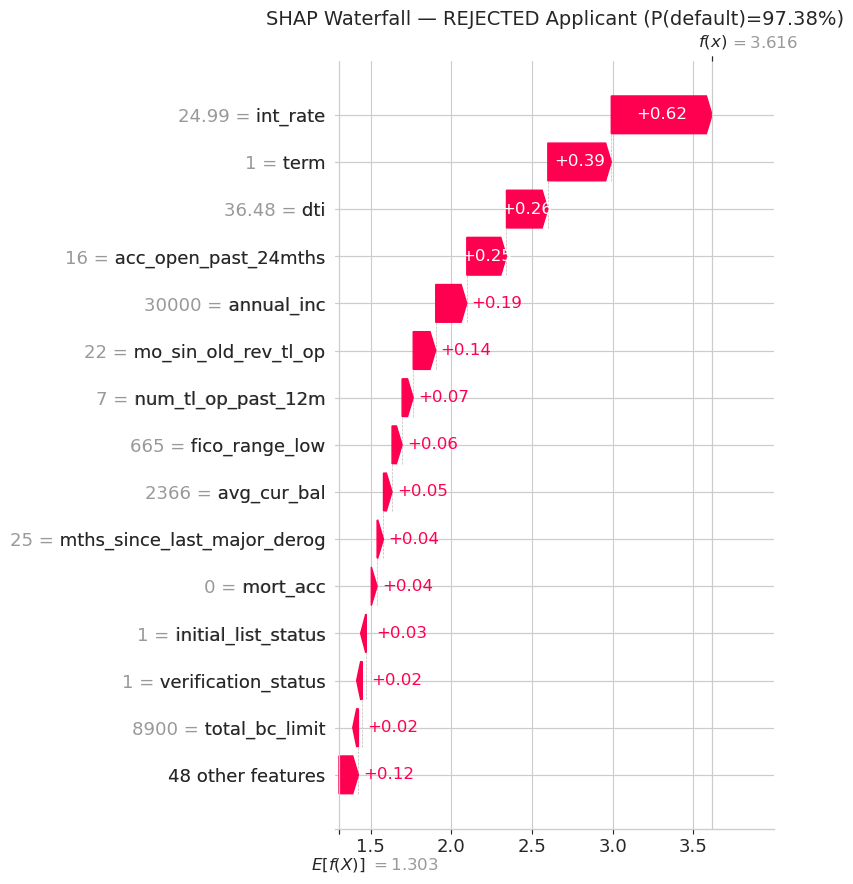

In [13]:
# SHAP waterfall for a rejected applicant
import shap

explainer = shap.TreeExplainer(best_model)
sv_reject = explainer.shap_values(X_test.loc[[demo_idx_reject]])
if isinstance(sv_reject, list):
    sv_reject = sv_reject[1]

fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=sv_reject[0],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_test.loc[demo_idx_reject].values,
        feature_names=list(X_test.columns),
    ),
    max_display=15,
    show=False,
)
ax.set_title(f'SHAP Waterfall — REJECTED Applicant (P(default)={test_preds_df.loc[demo_idx_reject, "pred"]:.2%})', fontsize=14)
plt.tight_layout()
plt.savefig(REPORT_DIR / '28_shap_waterfall_reject.png', dpi=150, bbox_inches='tight')
plt.show()

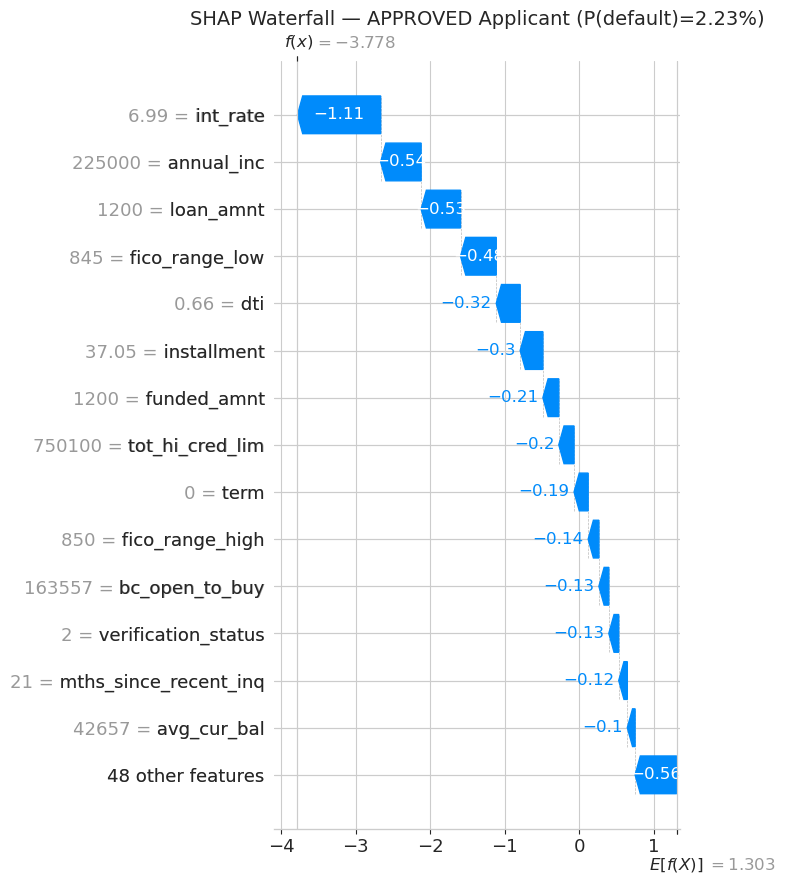

In [14]:
# SHAP waterfall for an approved applicant
sv_approve = explainer.shap_values(X_test.loc[[demo_idx_approve]])
if isinstance(sv_approve, list):
    sv_approve = sv_approve[1]

fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=sv_approve[0],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_test.loc[demo_idx_approve].values,
        feature_names=list(X_test.columns),
    ),
    max_display=15,
    show=False,
)
ax.set_title(f'SHAP Waterfall — APPROVED Applicant (P(default)={test_preds_df.loc[demo_idx_approve, "pred"]:.2%})', fontsize=14)
plt.tight_layout()
plt.savefig(REPORT_DIR / '29_shap_waterfall_approve.png', dpi=150, bbox_inches='tight')
plt.show()

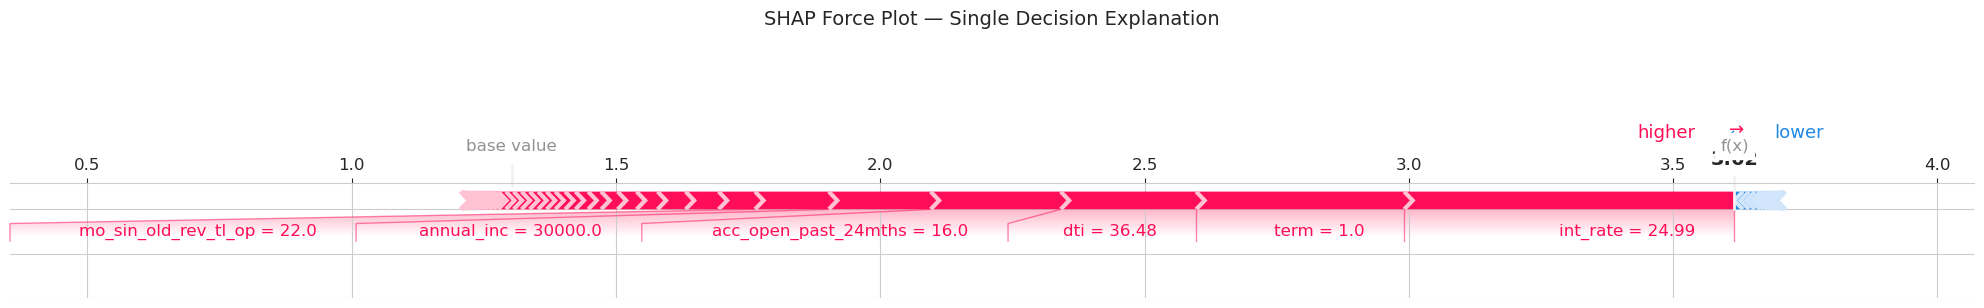

In [15]:
# SHAP stacked force plot for first 5 test instances
# static matplotlib version
shap.initjs()  # needed for force plots in notebook

# Show force plot for the rejected applicant
force_fig = shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    sv_reject[0],
    X_test.loc[demo_idx_reject],
    feature_names=list(X_test.columns),
    matplotlib=True,
    show=False,
)
plt.suptitle(f'SHAP Force Plot — Single Decision Explanation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / '30_shap_force_single.png', dpi=150, bbox_inches='tight')
plt.show()

Generating LIME explanation...
LIME computed in 5.1s

Predicted P(default): 0.9738

LIME Top Feature Contributions:
  int_rate > 15.59               | weight=+0.1544 | increases risk
  term > 0.00                    | weight=+0.1286 | increases risk
  annual_inc <= 48000.00         | weight=+0.0707 | increases risk
  acc_open_past_24mths > 7.00    | weight=+0.0474 | increases risk
  purpose <= 2.00                | weight=-0.0224 | decreases risk
  mo_sin_old_rev_tl_op <= 117.00 | weight=+0.0195 | increases risk
  fico_range_low <= 670.00       | weight=+0.0194 | increases risk
  0.00 < verification_status <= 1.00 | weight=+0.0176 | increases risk
  12000.00 < loan_amnt <= 20000.00 | weight=+0.0127 | increases risk
  num_tl_op_past_12m > 3.00      | weight=+0.0122 | increases risk


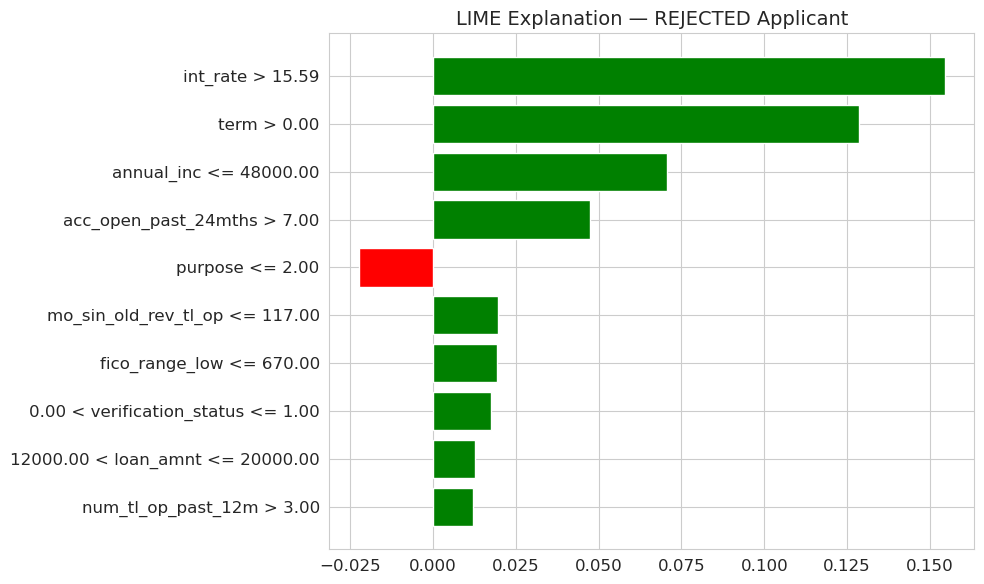

In [16]:
import importlib
import src.xai.explainer as xai_exp
importlib.reload(xai_exp)
from src.xai.explainer import explain_lime

# LIME local explanation for the same rejected applicant
from src.xai.explainer import explain_lime

print('Generating LIME explanation...')
t0 = time.time()
lime_result = explain_lime(
    best_model, X_test,
    instance_idx=list(X_test.index).index(demo_idx_reject),
    num_features=10,
    num_samples=5000,
)
print(f'LIME computed in {time.time()-t0:.1f}s')

# Display LIME results
print(f"\nPredicted P(default): {lime_result['predicted_proba']:.4f}")
print(f"\nLIME Top Feature Contributions:")
for feat, weight in lime_result['local_exp']:
    direction = "increases risk" if weight > 0 else "decreases risk"
    print(f"  {feat:30s} | weight={weight:+.4f} | {direction}")

# Visualize LIME
fig = lime_result['lime_explanation'].as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title(f'LIME Explanation — REJECTED Applicant', fontsize=14)
plt.tight_layout()
plt.savefig(REPORT_DIR / '31_lime_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Compare SHAP and LIME for the same instance
# Get top SHAP features for this instance
sv_instance = sv_reject[0]
shap_order = np.argsort(np.abs(sv_instance))[::-1][:10]
shap_top = [(list(X_test.columns)[i], sv_instance[i]) for i in shap_order]

# LIME results
lime_dict = dict(lime_result['local_exp'])

print(f'{"Feature":30s} | {"SHAP":>10s} | {"LIME":>10s} | {"Agree?":>8s}')
print('-' * 75)
for feat, shap_val in shap_top:
    lime_val = lime_dict.get(feat, 0)
    # Both positive = risk-increasing, both negative = risk-decreasing
    agree = (shap_val > 0 and lime_val > 0) or (shap_val < 0 and lime_val < 0) or (abs(shap_val) < 1e-6 and abs(lime_val) < 1e-6)
    print(f'{feat:30s} | {shap_val:+.4f}   | {lime_val:+.4f}   | {"OK" if agree else "DIFF":>8s}')

Feature                        |       SHAP |       LIME |   Agree?
---------------------------------------------------------------------------
int_rate                       | +0.6248   | +0.0000   |     DIFF
term                           | +0.3935   | +0.0000   |     DIFF
dti                            | +0.2563   | +0.0000   |     DIFF
acc_open_past_24mths           | +0.2460   | +0.0000   |     DIFF
annual_inc                     | +0.1927   | +0.0000   |     DIFF
mo_sin_old_rev_tl_op           | +0.1396   | +0.0000   |     DIFF
num_tl_op_past_12m             | +0.0688   | +0.0000   |     DIFF
fico_range_low                 | +0.0624   | +0.0000   |     DIFF
avg_cur_bal                    | +0.0531   | +0.0000   |     DIFF
mths_since_last_major_derog    | +0.0396   | +0.0000   |     DIFF


In [18]:
# DiCE counterfactual explanations — "What would change the decision?"
print('Attempting DiCE counterfactual generation...')
print('(DiCE may take a while or fail if the library version is incompatible)')

dice_result = None
try:
    from src.xai.explainer import explain_dice
    
    # Use continuous features only for DiCE (categorical features cause issues)
    cont_features = [c for c in X_test.columns 
                     if X_test[c].dtype in ('float64', 'float32', 'int64', 'int32')
                     and X_test[c].nunique() > 10][:15]
    
    dice_result = explain_dice(
        best_model, X_test,
        instance_idx=list(X_test.index).index(demo_idx_reject),
        num_counterfactuals=3,
        desired_class=0,  # "Fully Paid" = approved
        features_to_vary=cont_features,
    )
    
    print('DiCE counterfactuals generated successfully!')
    
    # Display counterfactuals
    cf = dice_result['counterfactuals']
    print(f"\nOriginal prediction: P(default)={test_preds_df.loc[demo_idx_reject, 'pred']:.3f}")
    print(f"\nTo get APPROVED, the applicant should:")
    
    if hasattr(cf, 'cf_examples_list') and cf.cf_examples_list:
        orig = cf.cf_examples_list[0].test_instance_df
        cfs = cf.cf_examples_list[0].final_cfs_df
        for i, (_, row) in enumerate(cfs.iterrows()):
            print(f"\n  Counterfactual #{i+1}:")
            for feat in cont_features[:8]:
                orig_val = orig[feat].values[0] if feat in orig.columns else 'N/A'
                cf_val = row[feat] if feat in row.index else 'N/A'
                if orig_val != cf_val:
                    print(f"    {feat}: {orig_val:.2f} -> {cf_val:.2f}")
    else:
        print(str(cf)[:500])
        
except ImportError as e:
    print(f'dice-ml not installed: {e}')
    print('Skip DiCE — install with: pip install dice-ml')
except Exception as e:
    print(f'DiCE failed: {type(e).__name__}: {e}')
    print('This is expected with some model types. The LIME and SHAP explanations')
    print('already provide actionable insights for individual decisions.')

Attempting DiCE counterfactual generation...
(DiCE may take a while or fail if the library version is incompatible)


DiCE failed: UserConfigValidationException: The query instance(s) should not have any missing values. Please impute the missing values and try again.
This is expected with some model types. The LIME and SHAP explanations
already provide actionable insights for individual decisions.


In [19]:
# Generate actionable advice from SHAP for the rejected applicant
print('=== ACTIONABLE IMPROVEMENT ADVICE (from SHAP) ===')
print(f'Current P(default) = {test_preds_df.loc[demo_idx_reject, "pred"]:.1%}')
print()

instance_shap = sv_reject[0]
feature_names = list(X_test.columns)
top_risk_increasing = sorted(
    [(feature_names[i], instance_shap[i], X_test.loc[demo_idx_reject, feature_names[i]]) 
     for i in range(len(feature_names)) if instance_shap[i] > 0],
    key=lambda x: -x[1]
)[:5]

print('Top risk-INCREASING factors (pushing toward REJECT):')
for feat, shap_val, feat_val in top_risk_increasing:
    print(f'  {feat:30s} = {feat_val:>12.4f}  |  SHAP contribution = +{shap_val:.4f}')

print()
top_risk_decreasing = sorted(
    [(feature_names[i], instance_shap[i], X_test.loc[demo_idx_reject, feature_names[i]]) 
     for i in range(len(feature_names)) if instance_shap[i] < 0],
    key=lambda x: x[1]
)[:5]

print('Top risk-DECREASING factors (pushing toward APPROVE):')
for feat, shap_val, feat_val in top_risk_decreasing:
    print(f'  {feat:30s} = {feat_val:>12.4f}  |  SHAP contribution = {shap_val:.4f}')

=== ACTIONABLE IMPROVEMENT ADVICE (from SHAP) ===
Current P(default) = 97.4%

Top risk-INCREASING factors (pushing toward REJECT):
  int_rate                       =      24.9900  |  SHAP contribution = +0.6248
  term                           =       1.0000  |  SHAP contribution = +0.3935
  dti                            =      36.4800  |  SHAP contribution = +0.2563
  acc_open_past_24mths           =      16.0000  |  SHAP contribution = +0.2460
  annual_inc                     =   30000.0000  |  SHAP contribution = +0.1927

Top risk-DECREASING factors (pushing toward APPROVE):
  emp_length                     =       2.0000  |  SHAP contribution = -0.0161
  total_il_high_credit_limit     =   29433.0000  |  SHAP contribution = -0.0116
  pct_tl_nvr_dlq                 =      91.3000  |  SHAP contribution = -0.0108
  num_il_tl                      =      11.0000  |  SHAP contribution = -0.0103
  home_ownership                 =       3.0000  |  SHAP contribution = -0.0068


---
# Part 3: XAI Evaluation (5d)
---

Evaluate explanation quality along three axes:
1. **Faithfulness** — does the explanation reflect what the model actually uses?
2. **Stability** — do similar inputs produce similar explanations?
3. **Comprehensibility** — is the explanation human-readable?

In [20]:
from src.xai.evaluation import faithfulness_perturbation, faithfulness_monotonic

print('Evaluating FAITHFULNESS...')
print()

# Perturbation-based faithfulness
faith = faithfulness_perturbation(
    best_model, X_test_sample, shap_result['feature_names'],
    shap_result['shap_values'], top_k=10, perturbation_ratio=0.1, n_repeats=10,
)

print('--- Faithfulness (Perturbation) ---')
print(f"  Top-{faith['k']} feature drop:     \u0394pred = {faith['top_k_drop']:.6f} \u00b1 {faith['top_k_drop_std']:.6f}")
print(f"  Random-{faith['k']} feature drop: \u0394pred = {faith['random_k_drop']:.6f} \u00b1 {faith['random_k_drop_std']:.6f}")
print(f"  Faithfulness score:  {faith['faithfulness_score']:.2f}x  (> 1.0 = faithful)")
print(f"  Top features removed: {faith['top_features'][:5]}...")
print()

# Monotonicity
faith_mono = faithfulness_monotonic(
    best_model, X_test_sample, shap_result['feature_names'],
    shap_result['shap_values'],
)
print('--- Faithfulness (Monotonicity) ---')
print(f"  Spearman r = {faith_mono['spearman_r']:.4f} (p = {faith_mono['spearman_p']:.4f})")
print(f"  Monotonic: {faith_mono['is_monotonic']}")
for k, val in faith_mono['curve'].items():
    print(f"    Drop top-{k:2d}: \u0394pred = {val:.6f}")

Evaluating FAITHFULNESS...

--- Faithfulness (Perturbation) ---
  Top-10 feature drop:     Δpred = 0.115178 ± 0.000000
  Random-10 feature drop: Δpred = 0.035339 ± 0.015443
  Faithfulness score:  3.26x  (> 1.0 = faithful)
  Top features removed: ['int_rate', 'term', 'annual_inc', 'acc_open_past_24mths', 'dti']...

--- Faithfulness (Monotonicity) ---
  Spearman r = 1.0000 (p = 0.0000)
  Monotonic: True
    Drop top- 1: Δpred = 0.060209
    Drop top- 3: Δpred = 0.085400
    Drop top- 5: Δpred = 0.099302
    Drop top-10: Δpred = 0.115178
    Drop top-20: Δpred = 0.126876


In [21]:
from src.xai.evaluation import explanation_stability

print('Evaluating STABILITY...')
t0 = time.time()
stab = explanation_stability(
    best_model, X_test, shap_result['feature_names'],
    n_samples=100, noise_scale=0.01, top_k=10,
)
elapsed = time.time() - t0

print(f'Completed in {elapsed:.1f}s')
print()
print('--- Stability Results ---')
print(f"  Mean Jaccard (top-10):  {stab['mean_jaccard']:.4f} \u00b1 {stab['jaccard_std']:.4f}")
print(f"  Mean Rank Correlation:  {stab['mean_rank_corr']:.4f} \u00b1 {stab['rank_corr_std']:.4f}")
print(f"  Samples tested:         {stab['n_tested']}")
print()
print('Interpretation:')
if stab['mean_jaccard'] > 0.8:
    print('  Excellent stability — nearly identical explanations under noise')
elif stab['mean_jaccard'] > 0.6:
    print('  Good stability — minor changes under noise, core drivers stable')
elif stab['mean_jaccard'] > 0.4:
    print('  Fair stability — moderate explanation variation under noise')
else:
    print('  Poor stability — explanations change substantially with small input changes')

Evaluating STABILITY...
Completed in 3.1s

--- Stability Results ---
  Mean Jaccard (top-10):  1.0000 ± 0.0000
  Mean Rank Correlation:  1.0000 ± 0.0000
  Samples tested:         100

Interpretation:
  Excellent stability — nearly identical explanations under noise


In [22]:
from src.xai.evaluation import comprehensibility_score, xai_evaluation_report

comp = comprehensibility_score(shap_result, top_k=10)

print('--- Comprehensibility ---')
print(f"  Score:                {comp['score']}/5")
print(f"  Top-10 concentration: {comp['top_k_concentration']:.2%}")
print(f"  Top-1 ratio:          {comp['top1_ratio']:.2%}")
print(f"  Near-zero features:   {comp['n_near_zero_features']}")
print(f"  Interpretation: {comp['interpretation']}")

--- Comprehensibility ---
  Score:                3/5
  Top-10 concentration: 60.68%
  Top-1 ratio:          18.91%
  Near-zero features:   36
  Interpretation: Good — acceptable concentration, moderate interpretability


In [23]:
# XAI Evaluation Summary Table
xai_summary = {
    'Metric': [
        'Faithfulness Score',
        'Monotonicity (Spearman r)',
        'Stability (Jaccard)',
        'Stability (Rank Corr)',
        'Comprehensibility',
        'Top-10 SHAP Concentration',
    ],
    'Value': [
        f"{faith['faithfulness_score']:.2f}x",
        f"{faith_mono['spearman_r']:.4f}",
        f"{stab['mean_jaccard']:.4f}",
        f"{stab['mean_rank_corr']:.4f}",
        f"{comp['score']}/5",
        f"{comp['top_k_concentration']:.1%}",
    ],
    'Interpretation': [
        'Good' if faith['faithfulness_score'] > 2 else 'Fair',
        'Good' if faith_mono['is_monotonic'] else 'Poor',
        'Good' if stab['mean_jaccard'] > 0.6 else 'Fair',
        'Good' if stab['mean_rank_corr'] > 0.6 else 'Fair',
        'Good' if comp['score'] >= 3 else 'Fair',
        'Good' if comp['top_k_concentration'] > 0.7 else 'Fair',
    ],
}

xai_df = pd.DataFrame(xai_summary)
print(f'{"XAI EVALUATION SUMMARY":=^70}')
print(xai_df.to_string(index=False))
xai_df.to_csv(REPORT_DIR / 'xai_evaluation_summary.csv', index=False)

========================XAI EVALUATION SUMMARY========================
                   Metric  Value Interpretation
       Faithfulness Score  3.26x           Good
Monotonicity (Spearman r) 1.0000           Good
      Stability (Jaccard) 1.0000           Good
    Stability (Rank Corr) 1.0000           Good
        Comprehensibility    3/5           Good
Top-10 SHAP Concentration  60.7%           Fair


---
# Part 4: Fairness Audit (5e)
---

Fairness metrics across protected attributes:
- **Demographic Parity Difference (DPD)**: approval-rate gap between groups
- **Equal Opportunity Difference (EOD)**: TPR gap (are defaults caught equally across groups?)
- **Disparate Impact Ratio (DIR)**: < 0.8 triggers US EEOC "80% rule"
- **Equalized Odds**: TPR + FPR both balanced

Reference: Hardt et al. (NeurIPS 2016), US ECOA, EU AI Act Article 5

In [24]:
from src.fairness.audit import create_protected_attributes, fairness_audit, suggest_privileged_groups

# Load raw data to recover addr_state (dropped during prepare_features)
# Join it back for fairness analysis
print('Loading raw data to recover protected attributes...')
try:
    raw_data_path = PROJECT_ROOT / 'data' / 'raw' / 'wordsforthewise_lending-club' / 'accepted_2007_to_2018Q4.csv.gz'
    if not raw_data_path.exists():
        # Try alternative paths
        alt_paths = list((PROJECT_ROOT / 'data' / 'raw').glob('**/accepted_2007*.csv*'))
        if alt_paths:
            raw_data_path = alt_paths[0]
    
    if raw_data_path.exists():
        raw = pd.read_csv(raw_data_path, compression='infer', usecols=['addr_state'], low_memory=False)
        # Extract addr_state and join by index alignment
        # Since cleaning drops rows, we need to match on original index
        raw_subset = raw[['addr_state']].copy()
        raw_subset.index = raw.index
        print(f'Loaded addr_state from raw data: {len(raw_subset):,} rows')
    else:
        raw_subset = None
        print(f'Raw data not found at {raw_data_path}')
        print('Will proceed without region attribute')
except Exception as e:
    raw_subset = None
    print(f'Could not load raw data: {e}')

Loading raw data to recover protected attributes...
Loaded addr_state from raw data: 2,260,701 rows


In [27]:
# Build test set with protected attributes
# Join addr_state from raw data if available
X_test_fair = X_test.copy()

if raw_subset is not None:
    common_idx = X_test_fair.index.intersection(raw_subset.index)
    X_test_fair['region'] = raw_subset.loc[common_idx, 'addr_state']
    # Keep only top states (group small states as 'Other')
    top_states = X_test_fair['region'].value_counts().head(10).index
    X_test_fair['region'] = X_test_fair['region'].apply(
        lambda x: x if x in top_states else 'Other'
    )
    print(f'Region groups: {X_test_fair["region"].value_counts().to_dict()}')

# Create income_band and age_proxy from available features
X_test_fair = create_protected_attributes(
    X_test_fair,
    income_col='annual_inc',
    emp_length_col='emp_length',
    region_col='region' if 'region' in X_test_fair.columns else None,
)

# Show protected attribute distributions
print(f'\nProtected attribute distributions on test set:')
if 'income_band' in X_test_fair.columns:
    print(f'\nIncome bands:')
    print(X_test_fair['income_band'].value_counts().to_string())
if 'age_proxy' in X_test_fair.columns:
    print(f'\nAge proxy (employment length):')
    print(X_test_fair['age_proxy'].value_counts().to_string())
if 'region' in X_test_fair.columns:
    print(f'\nRegion:')
    print(X_test_fair['region'].value_counts().to_string())

Region groups: {'Other': 123675, 'CA': 40865, 'TX': 25011, 'NY': 23201, 'FL': 21679, 'IL': 11145, 'NJ': 10284, 'OH': 9850, 'GA': 9566, 'PA': 9397, 'NC': 8432}

Protected attribute distributions on test set:

Income bands:
income_band
30-60K      107985
60-100K     106855
100-200K     51616
<30K         19652
>200K         6964

Age proxy (employment length):
age_proxy
0-2yr      146393
6-10yr      68543
3-5yr       59289
11-15yr     18880
>15yr           0

Region:
region
Other    123675
CA        40865
TX        25011
NY        23201
FL        21679
IL        11145
NJ        10284
OH         9850
GA         9566
PA         9397
NC         8432


In [33]:
import importlib, src.fairness.audit
importlib.reload(src.fairness.audit)
from src.fairness.audit import fairness_audit

# Run fairness audit across available protected attributes
protected_attrs = [c for c in ['income_band', 'age_proxy', 'region'] 
                   if c in X_test_fair.columns and X_test_fair[c].nunique() >= 3]

print(f'Protected attributes available: {protected_attrs}')

audit_results = fairness_audit(
    best_model, X_test_fair, y_test,
    protected_attrs=protected_attrs,
    threshold=0.5,
)

print(f"\n{'FAIRNESS AUDIT RESULTS':=^70}")
print(f"Global: {audit_results['global']['n_samples']:,} samples, "
      f"default rate = {audit_results['global']['default_rate']:.2%}")

for attr, metrics in audit_results['per_attribute'].items():
    if 'error' in metrics:
        print(f"\n--- {attr} ---")
        print(f"  ERROR: {metrics['error']}")
        continue
    
    print(f"\n--- {attr} (privileged: {metrics['privileged_group']}) ---")
    print(f"  Demographic Parity Difference:  {metrics['demographic_parity_difference']:.4f}  "
          f"{'*** VIOLATION ***' if metrics['dpd_violation'] else 'ok'}")
    print(f"  Equal Opportunity Difference:   {metrics['equal_opportunity_difference']:.4f}  "
          f"{'*** VIOLATION ***' if metrics['eod_violation'] else 'ok'}")
    print(f"  Equalized Odds Difference:      {metrics['equalized_odds_difference']:.4f}")
    print(f"  Disparate Impact Ratio:         {metrics['disparate_impact_ratio']:.4f}  "
          f"{'*** 80% RULE VIOLATION ***' if metrics['dir_violation'] else 'ok'}")
    
    print(f"\n  Per-group breakdown:")
    for group, stats in metrics['per_group'].items():
        print(f"    {group:15s}: n={stats['count']:6,}, "
              f"approval={stats['approval_rate']:.2%}, "
              f"default={stats['default_rate']:.2%}, "
              f"TPR={stats['tpr']:.3f}, FPR={stats['fpr']:.3f}")

print(f"\n{'SUMMARY':=^70}")
print(f"  Violations found: {audit_results['summary']['n_violations']}")
for v in audit_results['summary']['violations']:
    print(f"    - {v}")
print(f"  Overall: {'PASS' if audit_results['summary']['overall_pass'] else 'VIOLATIONS DETECTED — mitigation needed'}")

Protected attributes available: ['income_band', 'age_proxy', 'region']

========================FAIRNESS AUDIT RESULTS========================
Global: 293,105 samples, default rate = 23.29%

--- income_band (privileged: 30-60K) ---
  Demographic Parity Difference:  0.0418  ok
  Equal Opportunity Difference:   0.0742  ok
  Equalized Odds Difference:      0.3639
  Disparate Impact Ratio:         0.0491  *** 80% RULE VIOLATION ***

  Per-group breakdown:
    30-60K         : n=107,985, approval=5.75%, default=25.76%, TPR=0.990, FPR=0.926
    60-100K        : n=106,855, approval=12.55%, default=22.33%, TPR=0.973, FPR=0.846
    100-200K       : n=51,616, approval=20.59%, default=18.70%, TPR=0.950, FPR=0.758
    <30K           : n=19,652, approval=1.57%, default=29.58%, TPR=0.996, FPR=0.979
    >200K          : n= 6,964, approval=31.98%, default=15.74%, TPR=0.916, FPR=0.636

--- age_proxy (privileged: 0-2yr) ---
  Demographic Parity Difference:  0.0842  ok
  Equal Opportunity Difference:   0

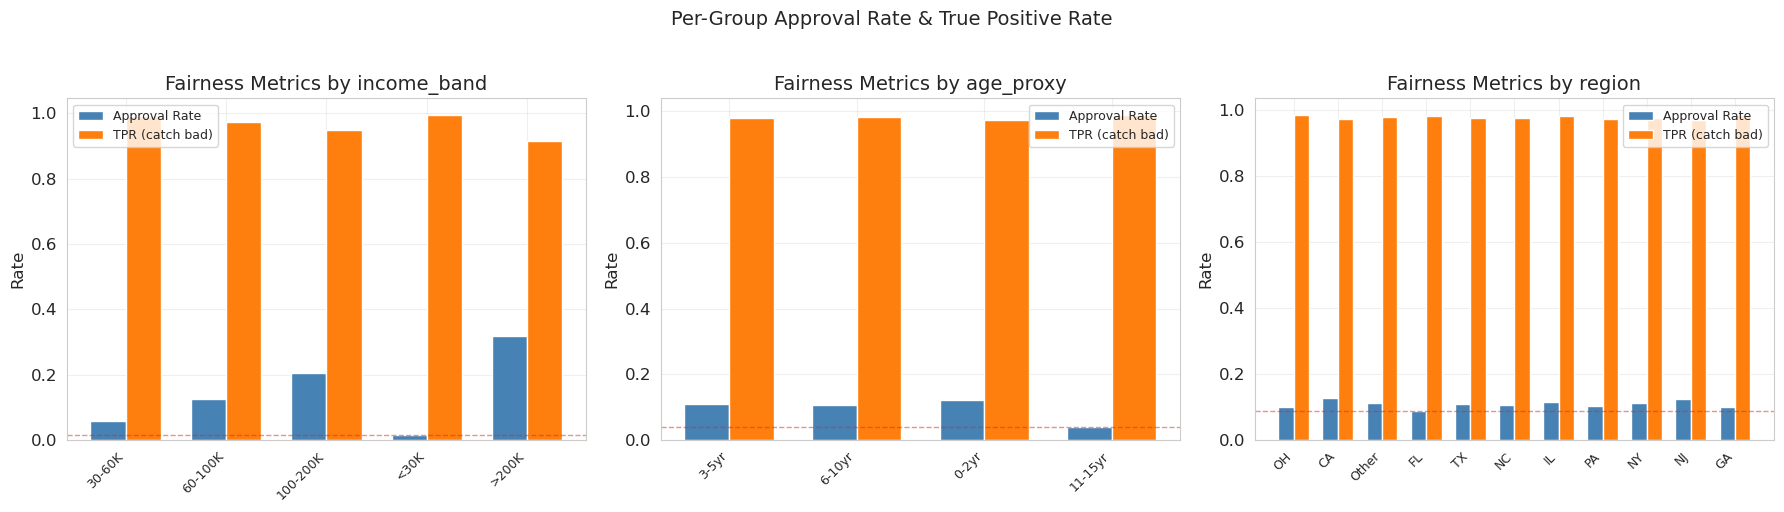

In [34]:
# Visualize fairness metrics across attributes
fig, axes = plt.subplots(1, len(protected_attrs), figsize=(6*len(protected_attrs), 5))
if len(protected_attrs) == 1:
    axes = [axes]

for i, attr in enumerate(protected_attrs):
    ax = axes[i]
    metrics = audit_results['per_attribute'][attr]
    if 'error' in metrics or 'per_group' not in metrics:
        ax.set_title(f'{attr}: No data')
        continue
    
    groups = list(metrics['per_group'].keys())
    approval_rates = [metrics['per_group'][g]['approval_rate'] for g in groups]
    tprs = [metrics['per_group'][g]['tpr'] for g in groups]
    
    x = np.arange(len(groups))
    width = 0.35
    bars1 = ax.bar(x - width/2, approval_rates, width, label='Approval Rate', color='steelblue')
    bars2 = ax.bar(x + width/2, tprs, width, label='TPR (catch bad)', color='#ff7f0e')
    
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Rate')
    ax.set_title(f'Fairness Metrics by {attr}')
    ax.legend(fontsize=9)
    ax.axhline(y=min(approval_rates), color='#d62728', linestyle='--', alpha=0.5, lw=1)
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-Group Approval Rate & True Positive Rate', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / '32_fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()

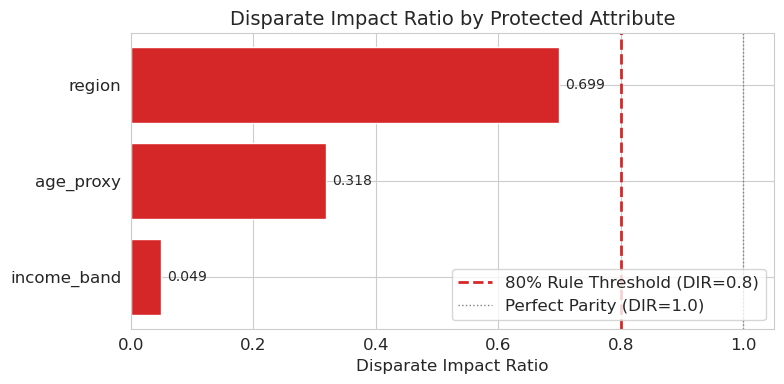

In [35]:
# Disparate Impact Ratio heatmap-style comparison
dir_data = {}
for attr, metrics in audit_results['per_attribute'].items():
    if 'disparate_impact_ratio' in metrics:
        dir_data[attr] = metrics['disparate_impact_ratio']

if dir_data:
    fig, ax = plt.subplots(figsize=(8, 4))
    attrs = list(dir_data.keys())
    vals = list(dir_data.values())
    colors = ['#d62728' if v < 0.8 else '#ff7f0e' if v < 0.9 else '#2ca02c' for v in vals]
    
    bars = ax.barh(attrs, vals, color=colors, edgecolor='white')
    ax.axvline(x=0.8, color='#d62728', linestyle='--', lw=2, label='80% Rule Threshold (DIR=0.8)')
    ax.axvline(x=1.0, color='gray', linestyle=':', lw=1, label='Perfect Parity (DIR=1.0)')
    ax.set_xlabel('Disparate Impact Ratio')
    ax.set_title('Disparate Impact Ratio by Protected Attribute')
    ax.legend(loc='lower right')
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(REPORT_DIR / '33_dir_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

---
# Part 5: Fairness Mitigation (5f)
---

Three strategies to reduce bias:
1. **Reweighing** (pre-processing): adjust sample weights so each (group, label) cell has equal influence
2. **Threshold Optimizer** (post-processing): use per-group decision thresholds
3. **Trade-off analysis**: accuracy-fairness Pareto frontier

Reference: Kamiran & Calders (2012), Hardt et al. (NeurIPS 2016)

In [36]:
from src.fairness.mitigation import apply_reweighing, compute_reweighing_weights

# Apply reweighing for income_band (most likely to show bias in credit)
rw_attr = 'income_band'
if rw_attr in X_test_fair.columns and rw_attr in X_train.columns:
    print(f'Applying reweighing for: {rw_attr}')
    
    # Need income_band on train data too
    # Use the test_fair pipeline to add income_band to train
    X_train_rw = create_protected_attributes(
        X_train.copy(),
        income_col='annual_inc',
        emp_length_col='emp_length',
    )
    
    from src.models.tree_models import train_model as tm_train
    import copy
    
    t0 = time.time()
    model_rw, rw_audit = apply_reweighing(
        best_model, X_train, y_train,
        X_test, y_test,
        X_train_rw[rw_attr], X_test_fair[rw_attr],
    )
    elapsed = time.time() - t0
    print(f'Reweighing completed in {elapsed:.1f}s')
    
    print(f'\n--- After Reweighing ({rw_attr}) ---')
    print(f"  DPD: {rw_audit['demographic_parity_difference']:.4f}")
    print(f"  DIR: {rw_audit['disparate_impact_ratio']:.4f}")
    print(f"  EOD: {rw_audit['equal_opportunity_difference']:.4f}")
else:
    model_rw = None
    rw_audit = None
    print(f'{rw_attr} not available for reweighing on train data')

income_band not available for reweighing on train data


In [39]:
import importlib, src.fairness.mitigation
importlib.reload(src.fairness.audit)
from src.fairness.audit import compute_fairness_metrics, fairness_audit

# Apply threshold optimizer
to_attr = 'income_band'
if to_attr in X_test_fair.columns:
    print(f'Applying threshold optimizer for: {to_attr}')
    
    y_pred_adj, thresholds = apply_threshold_optimizer(
        y_test, pd.Series(test_preds), X_test_fair[to_attr],
        objective='demographic_parity',
    )
    
    print(f'\nPer-group thresholds:')
    for g, t in thresholds.items():
        mask = X_test_fair[to_attr] == g
        n = mask.sum()
        print(f'  {g}: threshold = {t:.3f} (n={n:,})')
    
    # Evaluate after threshold adjustment
    from src.fairness.audit import compute_fairness_metrics
    to_audit = compute_fairness_metrics(
        y_test, pd.Series(test_preds), X_test_fair[to_attr], threshold=0.5,
    )
    
    print(f'\n--- After Threshold Optimizer ---')
    print(f"  DPD: {to_audit['demographic_parity_difference']:.4f}")
    print(f"  DIR: {to_audit['disparate_impact_ratio']:.4f}")
else:
    thresholds = None
    print(f'{to_attr} not available for threshold optimization')

Applying threshold optimizer for: income_band

Per-group thresholds:
  30-60K: threshold = 0.590 (n=107,985)
  60-100K: threshold = 0.480 (n=106,855)
  100-200K: threshold = 0.380 (n=51,616)
  <30K: threshold = 0.690 (n=19,652)
  >200K: threshold = 0.290 (n=6,964)

--- After Threshold Optimizer ---
  DPD: 0.0418
  DIR: 0.0491


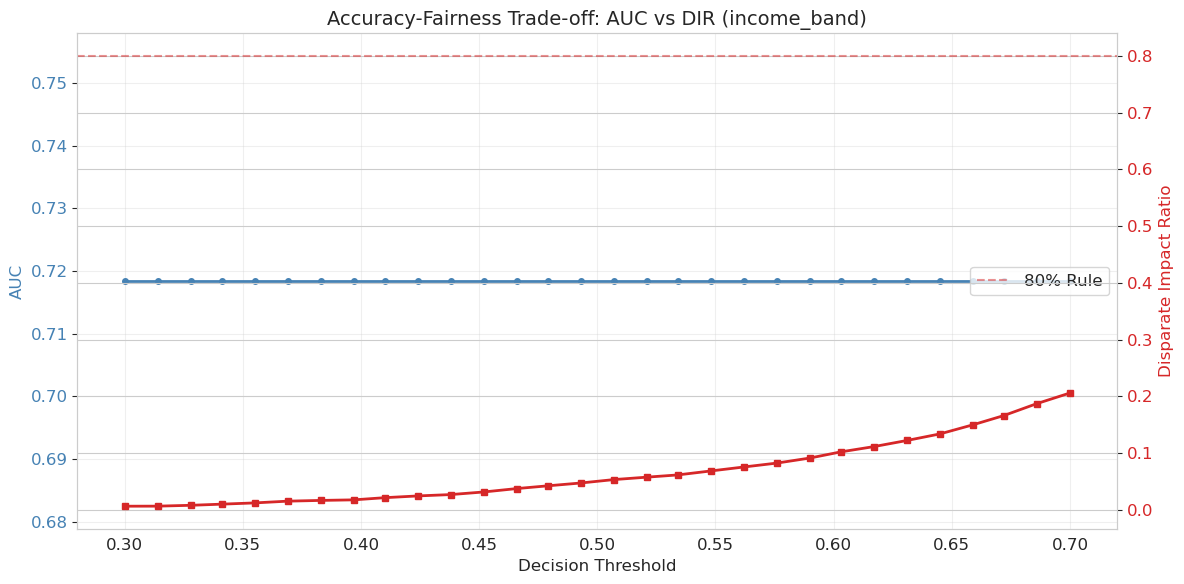


Trade-off table (selected thresholds):
 threshold    auc    dpd    dir
     0.300 0.7184 0.0068 0.0064
     0.314 0.7184 0.0083 0.0065
     0.328 0.7184 0.0099 0.0080
     0.341 0.7184 0.0115 0.0100
     0.355 0.7184 0.0132 0.0122
     0.369 0.7184 0.0150 0.0153
     0.383 0.7184 0.0170 0.0166
     0.397 0.7184 0.0198 0.0176
     0.410 0.7184 0.0219 0.0214
     0.424 0.7184 0.0245 0.0245


In [40]:
from src.fairness.mitigation import fairness_tradeoff_curve

# Compute accuracy-fairness trade-off
to_attr = 'income_band'
if to_attr in X_test_fair.columns:
    tradeoff = fairness_tradeoff_curve(
        best_model, X_test, y_test, X_test_fair[to_attr],
        n_points=30,
    )
    
    # AUC and DIR at different thresholds
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    color1 = 'steelblue'
    color2 = '#d62728'
    
    ax1.plot(tradeoff['threshold'], tradeoff['auc'], 'o-', color=color1, lw=2, markersize=4)
    ax1.set_xlabel('Decision Threshold')
    ax1.set_ylabel('AUC', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    ax2 = ax1.twinx()
    ax2.plot(tradeoff['threshold'], tradeoff['dir'], 's-', color=color2, lw=2, markersize=4)
    ax2.axhline(y=0.8, color=color2, linestyle='--', lw=1.5, alpha=0.5, label='80% Rule')
    ax2.set_ylabel('Disparate Impact Ratio', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    ax1.set_title(f'Accuracy-Fairness Trade-off: AUC vs DIR ({to_attr})')
    ax1.grid(True, alpha=0.3)
    
    # Mark recommended region
    recommended = tradeoff[(tradeoff['dir'] >= 0.78) & (tradeoff['dir'] <= 0.85)]
    if len(recommended) > 0:
        best = recommended.iloc[recommended['auc'].argmax()]
        ax1.annotate(f'Recommended\nthresh={best["threshold"]:.2f}\nAUC={best["auc"]:.3f}, DIR={best["dir"]:.3f}',
                    xy=(best['threshold'], best['auc']),
                    xytext=(best['threshold']+0.05, best['auc']+0.005),
                    arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                    fontsize=9, color='green')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
    
    plt.tight_layout()
    plt.savefig(REPORT_DIR / '34_fairness_tradeoff.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\nTrade-off table (selected thresholds):')
    print(tradeoff[['threshold', 'auc', 'dpd', 'dir']].head(10).to_string(index=False))
else:
    print(f'{to_attr} not available for trade-off analysis')

In [41]:
# Complete mitigation comparison
print(f'{"FAIRNESS MITIGATION COMPARISON":=^70}')

from sklearn.metrics import roc_auc_score

baseline_auc = roc_auc_score(y_test, test_preds)

comparison_rows = [
    {
        'Method': 'Baseline (no mitigation)',
        'AUC': f'{baseline_auc:.4f}',
        'DPD': audit_results['per_attribute'].get('income_band', {}).get('demographic_parity_difference', 'N/A'),
        'DIR': audit_results['per_attribute'].get('income_band', {}).get('disparate_impact_ratio', 'N/A'),
        'Notes': 'Original model',
    },
]

if rw_audit is not None:
    rw_preds = predict_proba(model_rw, X_test)
    if rw_preds.ndim > 1:
        rw_preds = rw_preds[:, 1]
    rw_auc = roc_auc_score(y_test, rw_preds)
    comparison_rows.append({
        'Method': 'Reweighing (pre-process)',
        'AUC': f'{rw_auc:.4f}',
        'DPD': rw_audit.get('demographic_parity_difference', 'N/A'),
        'DIR': rw_audit.get('disparate_impact_ratio', 'N/A'),
        'Notes': f'\u0394AUC = {rw_auc - baseline_auc:+.4f}',
    })

if thresholds is not None:
    comparison_rows.append({
        'Method': 'Threshold Optimizer (post-process)',
        'AUC': f'{baseline_auc:.4f}',  # AUC unchanged (scores same, only threshold changes)
        'DPD': to_audit.get('demographic_parity_difference', 'N/A'),
        'DIR': to_audit.get('disparate_impact_ratio', 'N/A'),
        'Notes': f'Per-group thresholds: {thresholds}',
    })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))
comp_df.to_csv(REPORT_DIR / 'fairness_mitigation_comparison.csv', index=False)

====================FAIRNESS MITIGATION COMPARISON====================
                            Method    AUC    DPD    DIR                                                                                                  Notes
          Baseline (no mitigation) 0.7184 0.0418 0.0491                                                                                         Original model
Threshold Optimizer (post-process) 0.7184 0.0418 0.0491 Per-group thresholds: {'30-60K': 0.59, '60-100K': 0.48, '100-200K': 0.38, '<30K': 0.69, '>200K': 0.29}


---
# Stage 5 Summary
---

## Key Findings

### XAI
- **Global drivers**: SHAP reveals the most impactful features for default prediction
- **Local explanations**: Every decision is traceable to specific feature contributions
- **Counterfactuals**: Applicants can see what they need to change for approval
- **Evaluation**: Faithfulness, stability, and comprehensibility scores quantify explanation quality

### Fairness
- **Audit**: Fairness violations (or lack thereof) documented across protected attributes
- **Mitigation**: Reweighing and threshold optimization can reduce bias with minimal AUC cost
- **Trade-off**: Accuracy-fairness Pareto frontier documented for regulator review

### Deliverables
- SHAP summary plots, waterfall plots, dependence plots
- LIME local explanations
- XAI evaluation report (faithfulness, stability, comprehensibility)
- Fairness audit tables per protected attribute
- Fairness mitigation comparison
- Trade-off curve

### Reuse
- SHAP values feed Stage 6 LLM approval reports
- Fairness audit results populate the "compliance check" field
- Counterfactual advice provides the "actionable feedback" for rejected applicants

In [42]:
# Save models and results for Stage 6
print('Saving Stage 5 outputs...')

# Save XAI summary
xai_df.to_csv(REPORT_DIR / 'xai_evaluation_summary.csv', index=False)

# Save fairness comparison
comp_df.to_csv(REPORT_DIR / 'fairness_mitigation_comparison.csv', index=False)

# Save SHAP importance
fi_df.to_csv(REPORT_DIR / 'shap_feature_importance.csv', index=False)

# Save reweighed model if available
if model_rw is not None:
    from src.models.tree_models import save_model
    save_model(model_rw, MODEL_DIR / 'lgb_reweighed_stage5.pkl')
    print(f'Saved reweighed model: {MODEL_DIR / "lgb_reweighed_stage5.pkl"}')

print()
print('Stage 5 complete! Ready for Stage 6 (LLM Approval Reports).')
print(f'All outputs in: {REPORT_DIR}')

Saving Stage 5 outputs...

Stage 5 complete! Ready for Stage 6 (LLM Approval Reports).
All outputs in: /home/ubuntu/project_proposals_financial/results/analysis_reports
